In [34]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
import itertools
from scipy.stats import spearmanr
import seaborn as sns
from statistics import mean, stdev
from math import sqrt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [35]:
df_total = pd.DataFrame()
for id, cntx in enumerate([1, 5, 10, 20, 30, 50, 100, 150, 200, 250]):
    df = pd.read_csv(f"../../result/RQ_Anomaly_Score/context_len_{cntx}.csv")
    df_total = pd.concat([df_total, df], ignore_index=True)
df_total["loss_min"] = df_total.groupby(['cntx_len']).loss.transform("min")
df_total["loss_max"] = df_total.groupby(['cntx_len']).loss.transform("max")
df_total["scaled_first_token_var_min"] = df_total.groupby(['cntx_len']).scaled_first_token_var.transform("min")
df_total["scaled_first_token_var_max"] = df_total.groupby(['cntx_len']).scaled_first_token_var.transform("max")
df_total["mask_ast_complexity_min"] = df_total.groupby(['cntx_len']).mask_ast_complexity.transform("min")
df_total["mask_ast_complexity_max"] = df_total.groupby(['cntx_len']).mask_ast_complexity.transform("max")
df_total["new_score"] = df_total.apply(
    lambda x: ((x.loss - x.loss_min) / (x.loss_max - x.loss_min)) + \
              ((x.scaled_first_token_var - x.scaled_first_token_var_min) / (x.scaled_first_token_var_max - x.scaled_first_token_var_min)) + \
              ((x.mask_ast_complexity - x.mask_ast_complexity_min) / (x.mask_ast_complexity_max - x.mask_ast_complexity_min)) - \
              (x.exact_match),
    axis=1
)

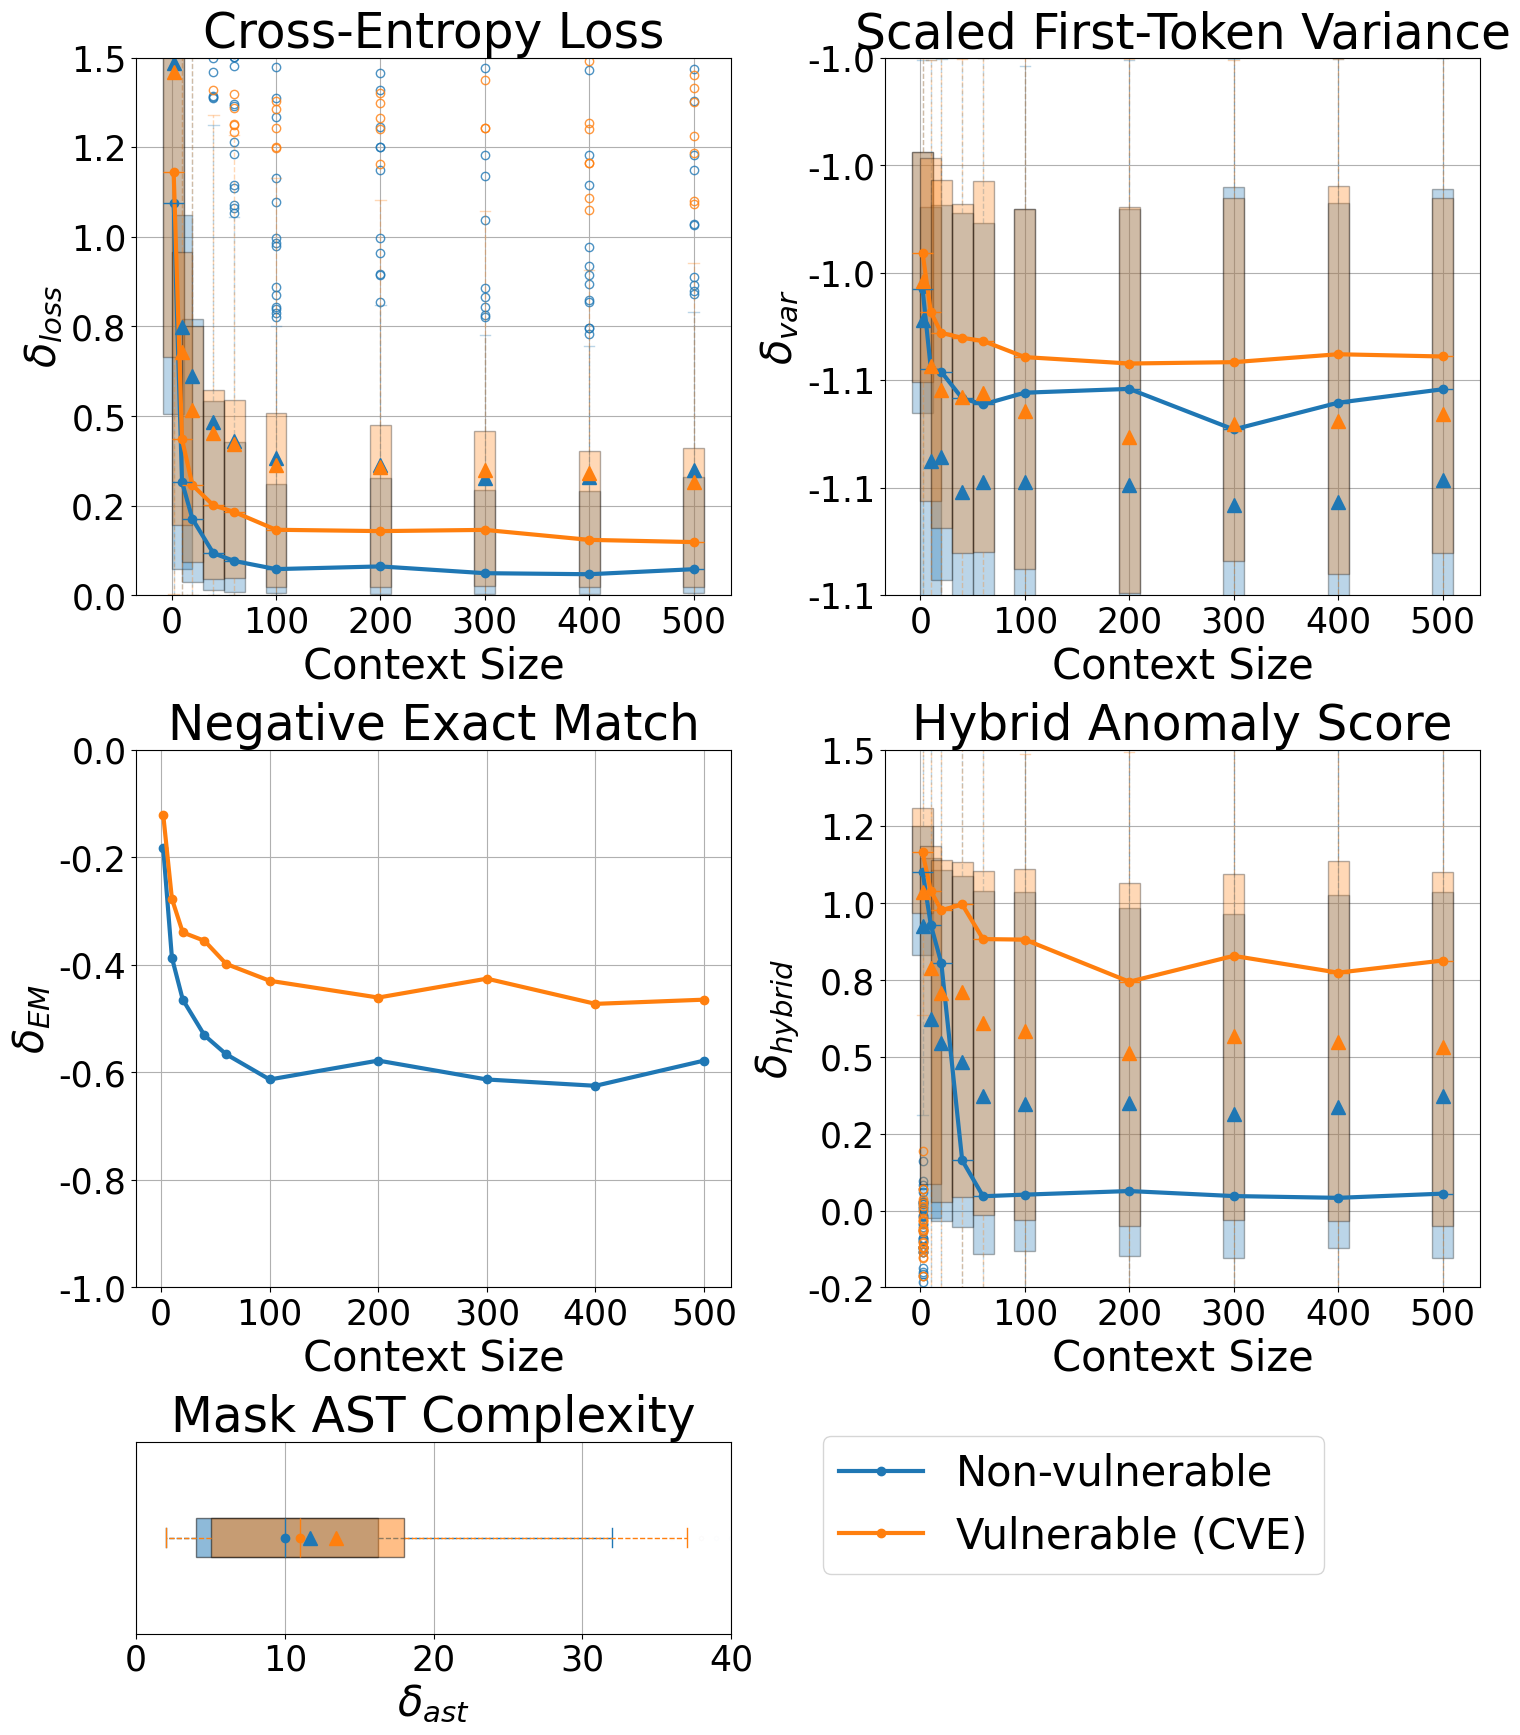

In [36]:
fig = plt.figure(figsize=(15,20))
gs = gridspec.GridSpec(12, 8)

df_vul = df_total[df_total.vul_label == 1]
df_nonvul = df_total[df_total.vul_label == 0]
axes = [[None, None, None], [None, None]]

# Plotting the loss distribution
axes[0][0] = plt.subplot(gs[0:4, 0:4])
axes[0][0].tick_params(axis='both', which='major', labelsize=25)
boxplot_loss_nonvul = df_nonvul[['cntx_len', 'loss']].groupby("cntx_len").loss.apply(func=list)
bp = axes[0][0].boxplot(boxplot_loss_nonvul, positions=(boxplot_loss_nonvul.index * 2).to_list(), widths=20, patch_artist=True, showmeans=True)
plt.setp(bp["boxes"], facecolor='C0', alpha=0.3)
plt.setp(bp["whiskers"], color='C0', linestyle='--', alpha=0.3)
plt.setp(bp["caps"], color='C0', alpha=0.3)
plt.setp(bp["medians"], color='C0', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C0', alpha=0.8)
plt.setp(bp["means"], markerfacecolor='C0', markeredgecolor="C0", alpha=1, markersize=10)
boxplot_loss_vul = df_vul[['cntx_len', 'loss']].groupby("cntx_len").loss.apply(func=list)
bp = axes[0][0].boxplot(boxplot_loss_vul, positions=(boxplot_loss_vul.index * 2).to_list(), widths=20, patch_artist=True, showmeans=True)
plt.setp(bp["boxes"], facecolor='C1', alpha=0.3)
plt.setp(bp["whiskers"], color='C1', linestyle='--', alpha=0.3)
plt.setp(bp["caps"], color='C1', alpha=0.3)
plt.setp(bp["medians"], color='C1', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C1', alpha=0.8)
plt.setp(bp["means"], markerfacecolor='C1', markeredgecolor="C1", alpha=1, markersize=10)
axes[0][0].plot((boxplot_loss_nonvul.index * 2).to_list(), np.median(np.vstack(boxplot_loss_nonvul.to_numpy()), axis=1), marker='o', label='Non-vulnerable', linewidth=3)
axes[0][0].plot((boxplot_loss_vul.index * 2).to_list(), np.median(np.vstack(boxplot_loss_vul.to_numpy()), axis=1), marker='o', label='Vulnerable (CVE)', linewidth=3)
axes[0][0].set_ylim(0, 1.5)
axes[0][0].grid()
axes[0][0].xaxis.set_major_locator(ticker.MultipleLocator(100))
axes[0][0].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes[0][0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
axes[0][0].set_title("Cross-Entropy Loss", fontsize=35)
axes[0][0].set_xlabel("Context Size", fontsize=30)
axes[0][0].set_ylabel(r"$\delta_{loss}$", fontsize=30)

# Plotting the first token variance distribution
axes[0][1] = plt.subplot(gs[0:4, 4:8])
axes[0][1].tick_params(axis='both', which='major', labelsize=25)
boxplot_scaled_first_token_var_nonvul = df_nonvul[['cntx_len', 'scaled_first_token_var']].groupby("cntx_len").scaled_first_token_var.apply(func=list)
bp = axes[0][1].boxplot(boxplot_scaled_first_token_var_nonvul, positions=(boxplot_scaled_first_token_var_nonvul.index * 2).to_list(), widths=20, patch_artist=True, showmeans=True)
plt.setp(bp["boxes"], facecolor='C0', alpha=0.3)
plt.setp(bp["whiskers"], color='C0', linestyle='--', alpha=0.3)
plt.setp(bp["caps"], color='C0', alpha=0.3)
plt.setp(bp["medians"], color='C0', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C0', alpha=0.8)
plt.setp(bp["means"], markerfacecolor='C0', markeredgecolor="C0", alpha=1, markersize=10)
boxplot_scaled_first_token_var_vul = df_vul[['cntx_len', 'scaled_first_token_var']].groupby("cntx_len").scaled_first_token_var.apply(func=list)
bp = axes[0][1].boxplot(boxplot_scaled_first_token_var_vul, positions=(boxplot_scaled_first_token_var_vul.index * 2).to_list(), widths=20, patch_artist=True, showmeans=True)
plt.setp(bp["boxes"], facecolor='C1', alpha=0.3)
plt.setp(bp["whiskers"], color='C1', linestyle='--', alpha=0.3)
plt.setp(bp["caps"], color='C1', alpha=0.3)
plt.setp(bp["medians"], color='C1', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C1', alpha=0.8)
plt.setp(bp["means"], markerfacecolor='C1', markeredgecolor="C1", alpha=1, markersize=10)
axes[0][1].plot((boxplot_scaled_first_token_var_nonvul.index * 2).to_list(), np.median(np.vstack(boxplot_scaled_first_token_var_nonvul.to_numpy()), axis=1), marker='o', label='Non-vulnerable', linewidth=3)
axes[0][1].plot((boxplot_scaled_first_token_var_vul.index * 2).to_list(), np.median(np.vstack(boxplot_scaled_first_token_var_vul.to_numpy()), axis=1), marker='o', label='Vulnerable (CVE)', linewidth=3)
axes[0][1].set_ylim(-1.1, -1)
axes[0][1].grid()
axes[0][1].xaxis.set_major_locator(ticker.MultipleLocator(100))
axes[0][1].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes[0][1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
axes[0][1].set_title("Scaled First-Token Variance", fontsize=35)
axes[0][1].set_xlabel("Context Size", fontsize=30)
axes[0][1].set_ylabel(r"$\delta_{var}$", fontsize=30)

# Plotting the EM accuracy distribution
axes[0][2] = plt.subplot(gs[4:8, 0:4])
axes[0][2].tick_params(axis='both', which='major', labelsize=25)
axes[0][2].plot((df_nonvul.groupby('cntx_len').exact_match.mean().index * 2).to_list(), -df_nonvul.groupby('cntx_len').exact_match.mean(), marker='o', label='Non-vulnerable', linewidth=3)
axes[0][2].plot((df_vul.groupby('cntx_len').exact_match.mean().index * 2).to_list(), -df_vul.groupby('cntx_len').exact_match.mean(), marker='o', label='Vulnerable (CVE)', linewidth=3)
axes[0][2].set_ylim(-1, 0)
axes[0][2].grid()
axes[0][2].xaxis.set_major_locator(ticker.MultipleLocator(100))
axes[0][2].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes[0][2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
axes[0][2].set_title("Negative Exact Match", fontsize=35)
axes[0][2].set_xlabel("Context Size", fontsize=30)
axes[0][2].set_ylabel(r"$\delta_{EM}$", fontsize=30)

# Plotting the Mask AST Complexity distribution
axes[1][0] = plt.subplot(gs[8:10, 0:4])
axes[1][0].tick_params(axis='both', which='major', labelsize=25)
bp = axes[1][0].boxplot(
    df_nonvul.groupby('cntx_len').mask_ast_complexity.apply(list).to_list()[0],
    tick_labels=["Mask AST Complexity"],
    vert=False, patch_artist=True, showmeans=True,
    widths=0.2
)
plt.setp(bp["boxes"], facecolor='C0', alpha=0.5)
plt.setp(bp["whiskers"], color='C0', linestyle='--', alpha=1)
plt.setp(bp["caps"], color='C0', alpha=1)
plt.setp(bp["medians"], color='C0', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C0', alpha=0.01, markersize=3, marker="o")
plt.setp(bp["means"], markerfacecolor='C0', markeredgecolor="C0", alpha=1, markersize=10)
meidan_nonvul_x = (bp["medians"][0].get_xdata()[0] + bp["medians"][0].get_xdata()[1]) / 2
meidan_nonvul_y = (bp["medians"][0].get_ydata()[0] + bp["medians"][0].get_ydata()[1]) / 2

bp = axes[1][0].boxplot(
    df_vul.groupby('cntx_len').mask_ast_complexity.apply(list).to_list()[0],
    tick_labels=["Mask AST Complexity"],
    vert=False, patch_artist=True, showmeans=True,
    widths=0.2
)
plt.setp(bp["boxes"], facecolor='C1', alpha=0.5)
plt.setp(bp["whiskers"], color='C1', linestyle='--', alpha=1)
plt.setp(bp["caps"], color='C1', alpha=1)
plt.setp(bp["medians"], color='C1', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C1', alpha=0.01, markersize=3, marker="o")
plt.setp(bp["means"], markerfacecolor='C1', markeredgecolor="C1", alpha=1, markersize=10)
meidan_vul_x = (bp["medians"][0].get_xdata()[0] + bp["medians"][0].get_xdata()[1]) / 2
meidan_vul_y = (bp["medians"][0].get_ydata()[0] + bp["medians"][0].get_ydata()[1]) / 2
axes[1][0].plot(meidan_nonvul_x, meidan_nonvul_y, marker='o', linewidth=3, color='C0')
axes[1][0].plot(meidan_vul_x, meidan_vul_y, marker='o', linewidth=3, color='C1')

axes[1][0].set_title("Mask AST Complexity", fontsize=35)
axes[1][0].set_xlabel(r"$\delta_{ast}$", fontsize=30)
plt.setp(axes[1][0], xlim=[0, 40])
# axes[1][0].legend(["non-vul", "vul"], loc="upper right", ncol=2)
axes[1][0].grid()
axes[1][0].get_yaxis().set_visible(False)

# Plotting the Anomaly Score distribution
axes[1][1] = plt.subplot(gs[4:8, 4:8])
axes[1][1].tick_params(axis='both', which='major', labelsize=25)
boxplot_new_score_nonvul = df_nonvul[['cntx_len', 'new_score']].groupby("cntx_len").new_score.apply(func=list)
bp = axes[1][1].boxplot(boxplot_new_score_nonvul, positions=(boxplot_new_score_nonvul.index * 2).to_list(), widths=20, patch_artist=True, showmeans=True)
plt.setp(bp["boxes"], facecolor='C0', alpha=0.3)
plt.setp(bp["whiskers"], color='C0', linestyle='--', alpha=0.3)
plt.setp(bp["caps"], color='C0', alpha=0.3)
plt.setp(bp["medians"], color='C0', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C0', alpha=0.8)
plt.setp(bp["means"], markerfacecolor='C0', markeredgecolor="C0", alpha=1, markersize=10)
boxplot_new_score_vul = df_vul[['cntx_len', 'new_score']].groupby("cntx_len").new_score.apply(func=list)
bp = axes[1][1].boxplot(boxplot_new_score_vul, positions=(boxplot_new_score_vul.index * 2).to_list(), widths=20, patch_artist=True, showmeans=True)
plt.setp(bp["boxes"], facecolor='C1', alpha=0.3)
plt.setp(bp["whiskers"], color='C1', linestyle='--', alpha=0.3)
plt.setp(bp["caps"], color='C1', alpha=0.3)
plt.setp(bp["medians"], color='C1', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C1', alpha=0.8)
plt.setp(bp["means"], markerfacecolor='C1', markeredgecolor="C1", alpha=1, markersize=10)
axes[1][1].plot((boxplot_new_score_nonvul.index * 2).to_list(), np.median(np.vstack(boxplot_new_score_nonvul.to_numpy()), axis=1), marker='o', label='Non-vulnerable', linewidth=3)
axes[1][1].plot((boxplot_new_score_vul.index * 2).to_list(), np.median(np.vstack(boxplot_new_score_vul.to_numpy()), axis=1), marker='o', label='Vulnerable (CVE)', linewidth=3)
axes[1][1].set_ylim(-0.25, 1.5)
axes[1][1].grid()
axes[1][1].xaxis.set_major_locator(ticker.MultipleLocator(100))
axes[1][1].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes[1][1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
axes[1][1].set_title("Hybrid Anomaly Score", fontsize=35)
axes[1][1].set_xlabel("Context Size", fontsize=30)
axes[1][1].set_ylabel(r"$\delta_{hybrid}$", fontsize=30)

handles, labels = axes[0][1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=30, ncol=1, bbox_to_anchor=(0.9, 0.2))
# fig.supxlabel('Anomaly Score', fontsize=35, x=-0.003)
plt.tight_layout()
plt.show()

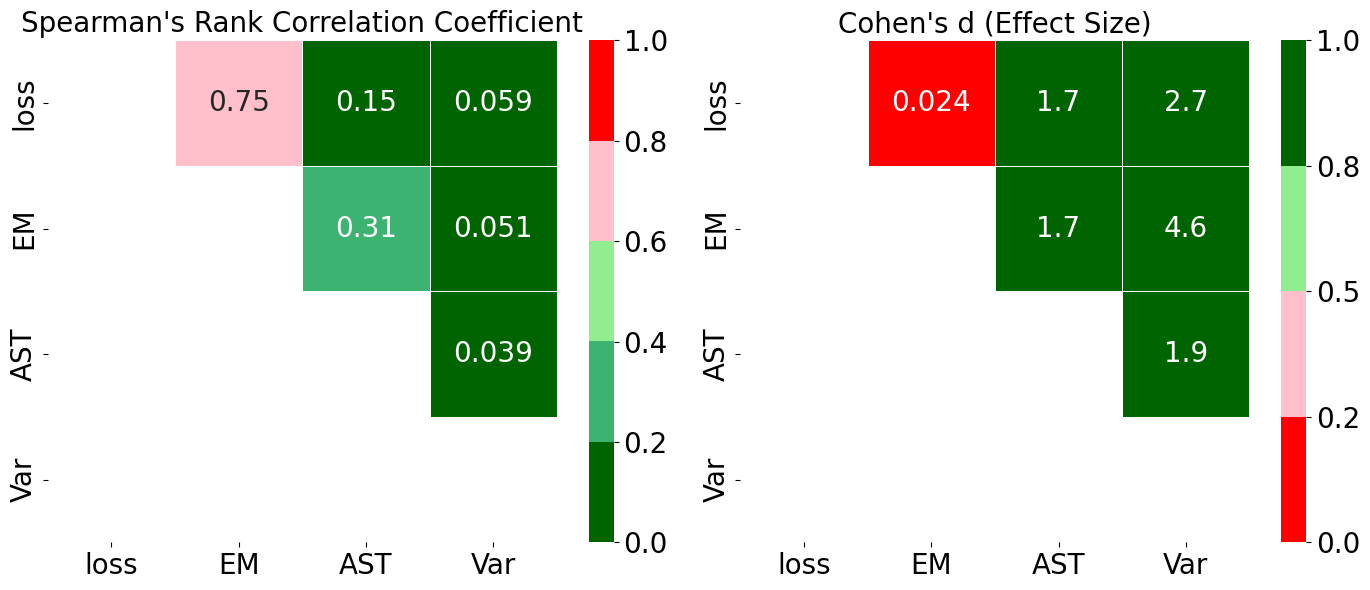

In [37]:
df_total["mask_ast_complexity"] = df_total["mask_ast_complexity"].astype(float)
df_total["neg_exact_match"] = df_total["neg_exact_match"].astype(float)
df_total = df_total[["loss", "neg_exact_match", "mask_ast_complexity", "scaled_first_token_var"]]

def cohens_d(x, y):
    return abs((mean(x) - mean(y)) / (sqrt((stdev(x) ** 2 + stdev(y) ** 2) / 2)))

spearmanr_matrix = pd.DataFrame(index=df_total.columns, columns=df_total.columns, dtype=float)
cohens_d_matrix = pd.DataFrame(index=df_total.columns, columns=df_total.columns, dtype=float)

for first, second in list(itertools.combinations(df_total.columns, 2)):
    score_first = df_total[first].to_numpy()
    score_second = df_total[second].to_numpy()

    # Perform Spearman's rank correlation
    spearman_stat, spearman_p = spearmanr(score_first, score_second)
    spearmanr_matrix.loc[first, second] = spearman_stat

    # Calculate rank-biserial correlation
    cohens_d_corr = cohens_d(score_first, score_second)
    cohens_d_matrix.loc[first, second] = cohens_d_corr

fig, axes = plt.subplots(ncols=2, figsize=(14, 6))

ticklabels = ["loss", "EM", "AST", "Var"]

colors = ["darkgreen", "mediumseagreen", "lightgreen", "pink", "red"]
bounds = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))
sns.heatmap(spearmanr_matrix.astype(float), annot=True, annot_kws={"size": 20}, cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': bounds}, ax=axes[0], linewidth=.5,
    xticklabels=ticklabels,
    yticklabels=ticklabels).collections[0].colorbar.ax.tick_params(labelsize=20)

colors = ["darkgreen", "lightgreen", "pink", "red"][-1::-1]  # Reverse the order for effect size
bounds = [0.0, 0.2, 0.5, 0.8, 1]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))
sns.heatmap(cohens_d_matrix.astype(float), annot=True, annot_kws={"size": 20},
    ax=axes[1], linewidth=.5, cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': bounds},
    xticklabels=ticklabels,
    yticklabels=ticklabels).collections[0].colorbar.ax.tick_params(labelsize=20)
axes[0].set_title("Spearman's Rank Correlation Coefficient", fontsize=20)
axes[0].tick_params(axis='both', which='major', labelsize=20)
axes[1].set_title("Cohen's d (Effect Size)", fontsize=20)
axes[1].tick_params(axis='both', which='major', labelsize=20)
plt.tight_layout()
plt.show()